# Tangential Smoothing Strategy Test

This notebook tests the **Tangential Smoothing** refinement strategy against the **Regular** (Laplacian) strategy.

**Strategies:**
1.  **Tangential Smoothing**: Decouples smoothing from shrinking by using Tangential Laplacian and Normal Consistency.
2.  **Regular**: Uses standard Laplacian smoothing on parameters (vertices or control points), which typically causes shrinking.

**Goal**: Verify that Tangential Smoothing prevents contour shrinkage while maintaining smoothness across different parameterizations.

In [ ]:
%load_ext autoreload
%autoreload 2

import copy
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from tqdm.notebook import tqdm

from diffmeshopt.opt2d.optimize import (
    BSplineContourRefiner,
    RBFContourRefiner,
    create_tangential_smoothing_refiner,
)
from diffmeshopt.opt2d.props import (
    BSplineContourRefinerProps,
    BSplineTemplateProps,
    NeuralFieldTemplateProps,
    RBFContourRefinerProps,
    RegularizerType,
    TemplateProps,
)
from diffmeshopt.opt2d.template import TemplateModelFactory
from diffmeshopt.opt2d.trainer import AtomicParquetLogger, OptimizationTrainer, TrainerConfig


Loading data from ../data/2d_training_data.pkl...


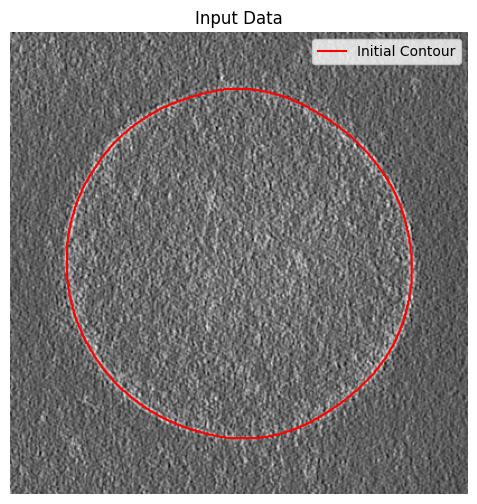

In [2]:
# 1. Load Data
data_path = Path("../data/2d_training_data.pkl")
if not data_path.exists():
    data_path = Path("/workspace/diffmeshopt/data/2d_training_data.pkl")

print(f"Loading data from {data_path}...")
data = joblib.load(data_path)
image_np = -data["image"]  # Invert intensity so membrane is dark
contour_np = data["contour"]
img_shape = image_np.shape

plt.figure(figsize=(6, 6))
plt.imshow(image_np, cmap="gray")
plt.plot(contour_np[:, 1], contour_np[:, 0], "r-", label="Initial Contour")
plt.legend()
plt.title("Input Data")
plt.axis("off")
plt.show()

In [3]:
# 2. Experiment Setup


def run_experiment(refiner_type, template_type, strategy="tangential", steps=500):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Base Props
    common_props = {
        "num_steps": steps,
        "learning_rate": 0.05,
        "num_sampled_profiles": 128,
        "initial_loss_weights": {},
    }

    # 1. Configure Refiner Props
    if refiner_type == "bspline":
        refiner_class = BSplineContourRefiner
        props = BSplineContourRefinerProps(
            **common_props,
            contour_num_control_points=100,  # High resolution for flexibility
        )
    elif refiner_type == "rbf":
        refiner_class = RBFContourRefiner
        props = RBFContourRefinerProps(
            **common_props, rbf_num_control_points=50, rbf_kernel_sigma=20.0
        )
    else:
        raise ValueError(f"Unknown refiner: {refiner_type}")

    # 2. Configure Template Props
    if template_type == "global":
        t_props = TemplateProps(symmetric=True)
    elif template_type == "bspline":
        t_props = BSplineTemplateProps(symmetric=True, bspline_num_control_points=16)
    elif template_type == "neural":
        t_props = NeuralFieldTemplateProps(symmetric=True, neural_hidden_dim=32)
    else:
        raise ValueError(f"Unknown template: {template_type}")

    # 3. Create Template Model
    template_model = TemplateModelFactory.create(
        template_type, props=t_props, num_vertices=len(contour_np), image_shape=img_shape
    ).to(device)

    # 4. Create Refiner
    contour_torch = torch.from_numpy(contour_np).float().to(device)

    if strategy == "tangential":
        # Tangential Smoothing: No shrinking forces, uses Tangential/Normal losses
        refiner = create_tangential_smoothing_refiner(
            refiner_class,
            initial_contour=contour_torch,
            props=props,
            template_model=template_model,
            adaptive=True,
            enable_adaptive_weights=False,
        )
    elif strategy == "regular":
        # Regular Smoothing: Standard Laplacian on parameters (causes shrinking)
        props.initial_loss_weights = {
            RegularizerType.CONTOUR_LAPLACIAN.value: 5.0,  # Strong smoothing
            RegularizerType.EDGE_LENGTH.value: 0.0,
            RegularizerType.TANGENTIAL_LAPLACIAN.value: 0.0,
            RegularizerType.NORMAL_CONSISTENCY.value: 0.0,
            RegularizerType.TEMPLATE_PARAM_ANCHOR.value: 0.1,
            RegularizerType.TEMPLATE_PARAM_LAPLACIAN.value: 1.0,
            RegularizerType.TEMPLATE_SHAPE.value: 1.0,
        }
        refiner = refiner_class(
            initial_contour=contour_torch, props=props, template_model=template_model
        )
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # 5. Run Training
    label = f"{refiner_type}_{template_type}_{strategy}"
    exp_dir = Path("../output/experiments/tangential_smoothing_test") / label
    if exp_dir.exists():
        shutil.rmtree(exp_dir)

    config = TrainerConfig(
        output_dir=exp_dir,
        image=image_np,
        gt_contour=None,
        save_images=True,
        use_tensorboard=True,
        log_interval=10,
        save_interval=200,
        max_steps=steps,
    )

    trainer = OptimizationTrainer(refiner, config, run_dir=exp_dir)
    trainer.fit(steps_to_run=steps)

    return trainer, label

In [6]:
# 3. Run All Combinations
refiners = ["bspline", "rbf"]
templates = ["global", "bspline", "neural"]
strategies = ["tangential", "regular"]

results = []

for refiner_type in refiners:
    for template_type in templates:
        for strategy in strategies:
            print(f"\n=== Running {refiner_type} + {template_type} ({strategy}) ===")
            trainer, label = run_experiment(refiner_type, template_type, strategy)

            # Collect results
            final_contour = trainer.refiner.contour.detach().cpu().numpy()

            # Calculate area change
            initial_area = 0.5 * np.abs(
                np.dot(contour_np[:, 0], np.roll(contour_np[:, 1], 1))
                - np.dot(contour_np[:, 1], np.roll(contour_np[:, 0], 1))
            )
            final_area = 0.5 * np.abs(
                np.dot(final_contour[:, 0], np.roll(final_contour[:, 1], 1))
                - np.dot(final_contour[:, 1], np.roll(final_contour[:, 0], 1))
            )
            area_change = (final_area - initial_area) / initial_area * 100

            # Get final loss
            logger = next(
                (l for l in trainer.trainer.loggers if isinstance(l, AtomicParquetLogger)), None
            )
            final_loss = logger.history[-1]["total_loss"] if logger and logger.history else np.nan

            results.append(
                {
                    "Refiner": refiner_type,
                    "Template": template_type,
                    "Strategy": strategy,
                    "Label": label,
                    "Final Loss": final_loss,
                    "Area Change (%)": area_change,
                    "Contour": final_contour,
                }
            )


=== Running bspline + global (tangential) ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0: 100%|##| 500/500 [00:13<00:00, 38.08it/s, v_num=.0_0, total_loss=0.733]

`Trainer.fit` stopped: `max_steps=500` reached.


                                                                                
=== Running bspline + global (regular) ===


...

`Trainer.fit` stopped: `max_steps=500` reached.


                                                                                
=== Running rbf + neural (regular) ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0: 100%|###| 500/500 [00:12<00:00, 38.46it/s, v_num=.0_0, total_loss=1.15]

`Trainer.fit` stopped: `max_steps=500` reached.



=== Results Summary ===
shape: (12, 6)
┌─────────┬──────────┬────────────┬────────────────────────────┬────────────┬─────────────────┐
│ Refiner ┆ Template ┆ Strategy   ┆ Label                      ┆ Final Loss ┆ Area Change (%) │
│ ---     ┆ ---      ┆ ---        ┆ ---                        ┆ ---        ┆ ---             │
│ str     ┆ str      ┆ str        ┆ str                        ┆ f64        ┆ f64             │
╞═════════╪══════════╪════════════╪════════════════════════════╪════════════╪═════════════════╡
│ bspline ┆ bspline  ┆ regular    ┆ bspline_bspline_regular    ┆ 4.371294   ┆ -1.402672       │
│ bspline ┆ bspline  ┆ tangential ┆ bspline_bspline_tangential ┆ 0.705567   ┆ -0.493842       │
│ bspline ┆ global   ┆ regular    ┆ bspline_global_regular     ┆ 4.333675   ┆ -1.437421       │
│ bspline ┆ global   ┆ tangential ┆ bspline_global_tangential  ┆ 0.732877   ┆ -0.520572       │
│ bspline ┆ neural   ┆ regular    ┆ bspline_neural_regular     ┆ 4.25812    ┆ -1.442767       │


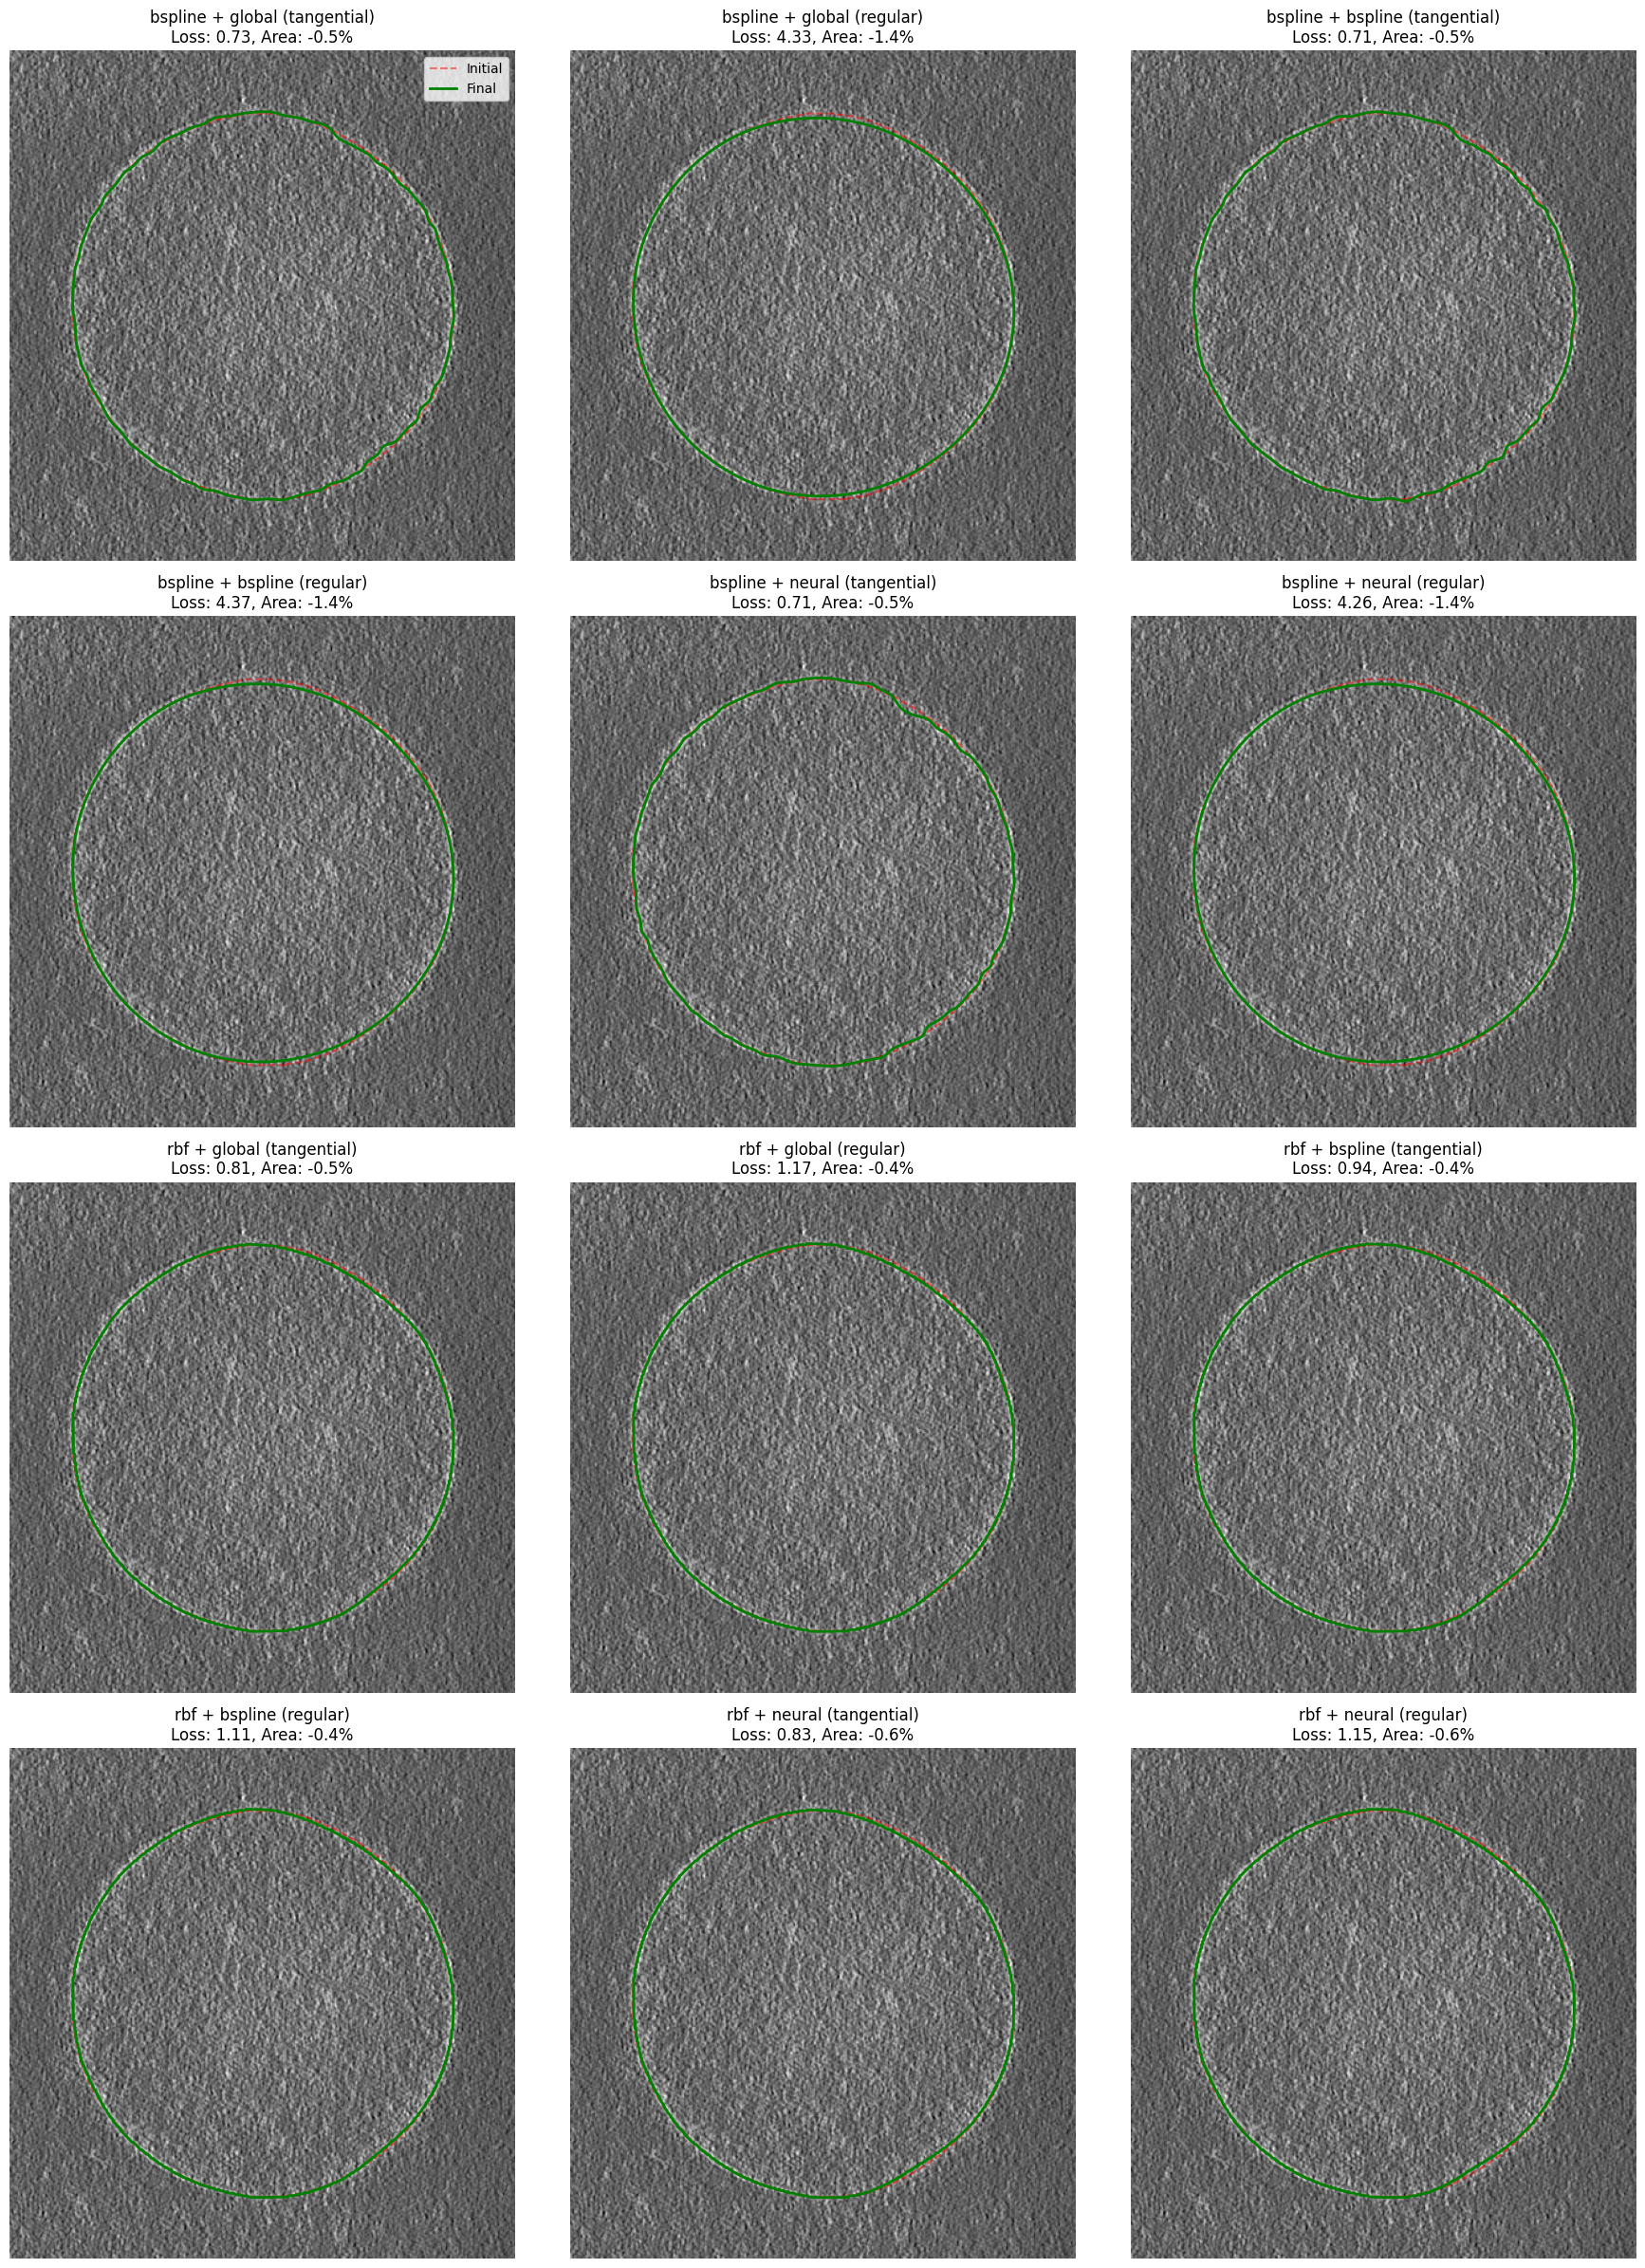

In [7]:
# 4. Analysis
df = pl.DataFrame([{k: v for k, v in r.items() if k != "Contour"} for r in results])
print("\n=== Results Summary ===")
print(df.sort(["Refiner", "Template", "Strategy"]))

# Visualization
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    ax.imshow(image_np, cmap="gray")
    ax.plot(contour_np[:, 1], contour_np[:, 0], "r--", label="Initial", alpha=0.5)

    final = res["Contour"]
    ax.plot(final[:, 1], final[:, 0], "g-", label="Final", linewidth=2)

    title = f"{res['Refiner']} + {res['Template']} ({res['Strategy']})\nLoss: {res['Final Loss']:.2f}, Area: {res['Area Change (%)']:.1f}%"
    ax.set_title(title)
    ax.axis("off")
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

=== Summary Statistics ===
Total experiments: 12

Overall statistics:
shape: (1, 4)
┌────────────────┬─────────────────┬───────────────┬───────────────┐
│ Avg Final Loss ┆ Avg Area Change ┆ Avg Roughness ┆ Avg Perimeter │
│ ---            ┆ ---             ┆ ---           ┆ ---           │
│ f64            ┆ f64             ┆ f64           ┆ f64           │
╞════════════════╪═════════════════╪═══════════════╪═══════════════╡
│ 1.760031       ┆ -0.715258       ┆ 0.066452      ┆ 995.744339    │
└────────────────┴─────────────────┴───────────────┴───────────────┘

=== Best Configurations ===

Top 5 by Final Loss (data fit):
shape: (5, 5)
┌─────────┬──────────┬────────────┬────────────┬─────────────────┐
│ Refiner ┆ Template ┆ Strategy   ┆ Final Loss ┆ Area Change (%) │
│ ---     ┆ ---      ┆ ---        ┆ ---        ┆ ---             │
│ str     ┆ str      ┆ str        ┆ f64        ┆ f64             │
╞═════════╪══════════╪════════════╪════════════╪═════════════════╡
│ bspline ┆ bspline  ┆

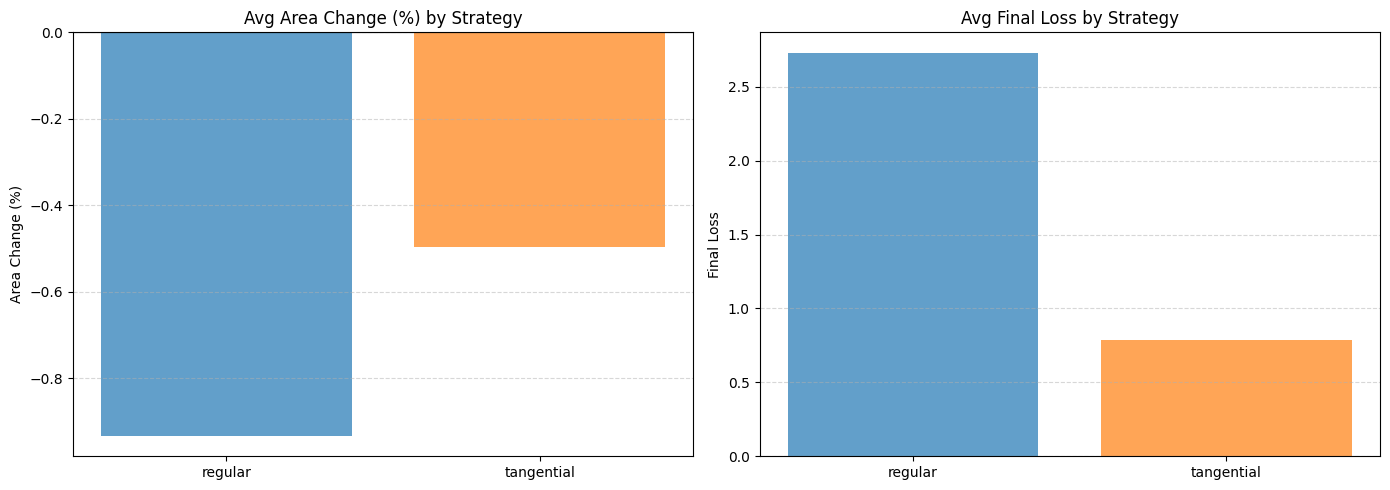

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from diffmeshopt.opt2d.evaluation import compute_reference_free_metrics

# 4. Quantitative Comparison (Tables & Visualizations)
if not results:
    print("No results to display.")
else:
    # Enrich results with geometric metrics
    for res in results:
        if "Contour" in res:
            # Calculate metrics if not present
            metrics = compute_reference_free_metrics(res["Contour"])
            res["Roughness"] = metrics.get("roughness", np.nan)
            res["Perimeter"] = metrics.get("perimeter", np.nan)

    # Filter out complex objects for DataFrame
    simple_results = [
        {
            k: v
            for k, v in r.items()
            if k not in ["Contour", "Template Params", "Loss History", "RefinerObj"]
        }
        for r in results
    ]
    df = pl.DataFrame(simple_results)

    print("=== Summary Statistics ===")
    print(f"Total experiments: {len(df)}")
    print("\nOverall statistics:")
    print(
        df.select(
            [
                pl.col("Final Loss").mean().alias("Avg Final Loss"),
                pl.col("Area Change (%)").mean().alias("Avg Area Change"),
                pl.col("Roughness").mean().alias("Avg Roughness"),
                pl.col("Perimeter").mean().alias("Avg Perimeter"),
            ]
        )
    )

    # Find best configurations by different metrics
    print("\n=== Best Configurations ===")

    # Best by final loss
    best_loss = df.sort("Final Loss").head(5)
    print("\nTop 5 by Final Loss (data fit):")
    print(
        best_loss.select(
            [
                "Refiner",
                "Template",
                "Strategy",
                "Final Loss",
                "Area Change (%)",
            ]
        )
    )

    # Configurations with minimal shrinkage
    df_with_abs_area = df.with_columns(pl.col("Area Change (%)").abs().alias("Abs Area Change"))
    best_area_preservation = df_with_abs_area.sort("Abs Area Change").head(5)
    print("\nTop 5 by Area Preservation:")
    print(
        best_area_preservation.select(
            [
                "Refiner",
                "Template",
                "Strategy",
                "Area Change (%)",
                "Final Loss",
            ]
        )
    )

    # Analyze effect of each variable
    print("\n=== Factor Analysis ===")

    factors = ["Strategy", "Refiner", "Template"]
    for factor in factors:
        print(f"\n--- By {factor} ---")
        stats = (
            df.group_by(factor)
            .agg(
                [
                    pl.col("Final Loss").mean().alias("Avg Final Loss"),
                    pl.col("Area Change (%)").mean().alias("Avg Area Change"),
                    pl.col("Roughness").mean().alias("Avg Roughness"),
                    pl.len().alias("Count"),
                ]
            )
            .sort("Avg Final Loss")
        )
        print(stats)

    # Visualizations
    print("\n=== Visualization: Strategy Comparison ===")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Area Change by Strategy
    ax = axes[0]
    # Aggregate by Strategy
    strat_data = df.group_by("Strategy").agg(pl.col("Area Change (%)").mean()).sort("Strategy")
    # Convert to pandas/numpy for plotting
    ax.bar(
        strat_data["Strategy"],
        strat_data["Area Change (%)"],
        alpha=0.7,
        color=["tab:blue", "tab:orange"],
    )
    ax.set_title("Avg Area Change (%) by Strategy")
    ax.set_ylabel("Area Change (%)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Final Loss by Strategy
    ax = axes[1]
    loss_data = df.group_by("Strategy").agg(pl.col("Final Loss").mean()).sort("Strategy")
    ax.bar(
        loss_data["Strategy"], loss_data["Final Loss"], alpha=0.7, color=["tab:blue", "tab:orange"]
    )
    ax.set_title("Avg Final Loss by Strategy")
    ax.set_ylabel("Final Loss")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [ ]:

# 5. Qualitative Comparison: Top Configurations - Largest Deviation Crops
if not results:
    print("No results to visualize.")
else:
    # Select top results by Final Loss
    sorted_results = sorted(results, key=lambda x: x.get("Final Loss", float("inf")))
    top_results = sorted_results[:6]

    print(f"Visualizing top combinations (by Final Loss) - Largest Deviation Crops:")

    # Setup cropping
    num_crops = 4
    crop_size = 60
    H, W = image_np.shape[:2]
    half_size = crop_size // 2

    # Find crop locations with largest deviations from initial contour
    crop_indices = []
    if len(contour_np) > 0 and top_results:
        # Calculate distances between initial and the best final contour
        best_contour = top_results[0]["Contour"]
        distances = np.linalg.norm(contour_np - best_contour, axis=1)

        # Get indices of largest deviations, filtering for spatial separation
        sorted_indices = np.argsort(distances)[::-1]
        picked = []
        for idx in sorted_indices:
            if len(picked) >= num_crops:
                break
            # Simple check to ensure crops don't overlap too much (assuming sequential indices roughly correspond to spatial proximity)
            if all(abs(idx - p) > len(contour_np) // 15 for p in picked):
                picked.append(idx)

        if not picked:
            picked = sorted_indices[:num_crops].tolist()
        crop_indices = sorted(picked)

    fig, axes = plt.subplots(
        len(top_results),
        num_crops,
        figsize=(3 * num_crops, 3 * len(top_results)),
        constrained_layout=True,
    )

    # Handle dimensions for single row/col
    if len(top_results) == 1:
        axes = axes[None, :]
    if num_crops == 1:
        axes = axes[:, None]

    for i, res in enumerate(top_results):
        final_contour = res["Contour"]

        for j, idx in enumerate(crop_indices):
            ax = axes[i, j]

            # Crop center from initial contour
            cy, cx = contour_np[idx]
            y_min = max(0, int(cy - half_size))
            y_max = min(H, int(cy + half_size))
            x_min = max(0, int(cx - half_size))
            x_max = min(W, int(cx + half_size))

            ax.imshow(image_np, cmap="gray")

            # Plot contours
            ax.plot(contour_np[:, 1], contour_np[:, 0], "r--", alpha=0.5, lw=1, label="Init")
            ax.plot(
                final_contour[:, 1], final_contour[:, 0], "g-", alpha=0.8, lw=1.5, label="Final"
            )

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_max, y_min)
            ax.axis("off")

            if j == 0:
                # Add label on the left
                label_text = (
                    f"{res['Refiner']}\n{res['Template']}\n{res['Strategy']}\n"
                    f"L:{res['Final Loss']:.2f} A:{res['Area Change (%)']:.1f}%"
                )
                ax.text(
                    -0.1,
                    0.5,
                    label_text,
                    transform=ax.transAxes,
                    va="center",
                    ha="right",
                    fontsize=9,
                    rotation=0,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                )

    plt.suptitle("Top Results: Largest Deviation Crops (Red=Init, Green=Final)", fontsize=14)
    plt.show()